Running Scaling Relation Simulation...


100%|██████████| 3000/3000 [00:09<00:00, 303.17it/s]


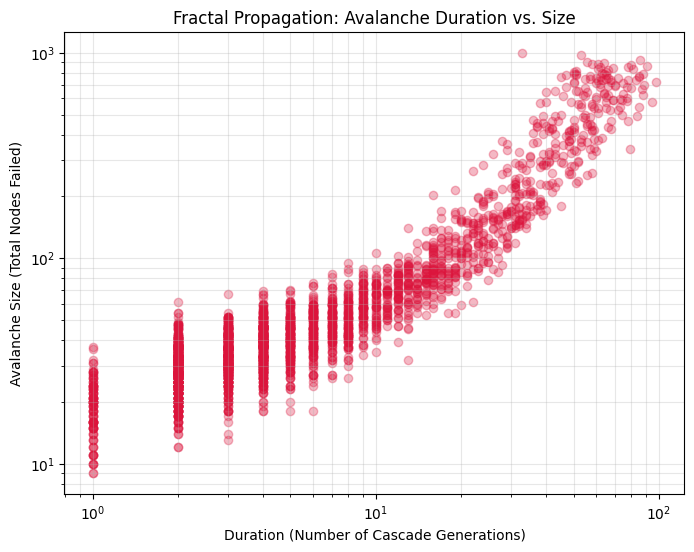

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

def analyze_duration_vs_size(NUM_NODES=1000, RADIUS=0.05, TOL=0.20, NOISE=0.8, STEPS=3000):
    G = nx.random_geometric_graph(NUM_NODES, radius=RADIUS)

    for node in G.nodes():
        load = np.random.uniform(0, 10)
        G.nodes[node]['load'] = load
        G.nodes[node]['capacity'] = load * (1 + TOL)
        G.nodes[node]['tripped'] = False

    cascade_data = [] # Stores (Duration, Size)

    print("Running Scaling Relation Simulation...")
    for step in tqdm(range(STEPS)):
        for node in G.nodes(): G.nodes[node]['load'] += (NOISE / 10.0)

        current_avalanche_size = 0
        current_duration = 0

        while True:
            overloaded = [n for n, d in G.nodes(data=True) if d['load'] > d['capacity'] and not d['tripped']]
            if not overloaded: break

            current_duration += 1 # Each loop is one 'generation' or tick of the cascade

            for node in overloaded:
                overload_amt = G.nodes[node]['load']
                G.nodes[node]['load'] = 0
                G.nodes[node]['tripped'] = True
                current_avalanche_size += 1

                active_nbrs = [nbr for nbr in G.neighbors(node) if not G.nodes[nbr]['tripped']]
                if active_nbrs:
                    spill = overload_amt / len(active_nbrs)
                    for nbr in active_nbrs: G.nodes[nbr]['load'] += spill

        if current_avalanche_size > 0:
            cascade_data.append((current_duration, current_avalanche_size))

        for node in G.nodes(): G.nodes[node]['tripped'] = False

    return cascade_data

# --- PLOTTING ---
data = analyze_duration_vs_size()
durations = [d[0] for d in data]
sizes = [d[1] for d in data]

plt.figure(figsize=(8, 6))
plt.scatter(durations, sizes, alpha=0.3, color='crimson')
plt.title("Fractal Propagation: Avalanche Duration vs. Size")
plt.xlabel("Duration (Number of Cascade Generations)")
plt.ylabel("Avalanche Size (Total Nodes Failed)")
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which="both", alpha=0.3)
plt.show()